This file will be used to explore Kilosort4 output data.

In [ ]:
# imports 
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec, rcParams
import os
import pathlib

import spikeinterface as si
from probeinterface import Probe

from dataLoading_utils import getXMLData
import spikeinterface.preprocessing as spre


%matplotlib inline

In [3]:
# outputs saved to results_dir
results_dir = r"C:\Users\social\Desktop\temp_Brune\viktor08_kilosort4"

#pathlib.WindowsPath = pathlib.PosixPath

In [ ]:
dat_path = r"E:\Data\mPG_VV\3170_day8_260415_170145\amplifier.dat"
xml_path = r"E:\Data\mPG_VV\3170_day8_260415_170145\amplifier.xml"

channel_ids, skippedChannels, xml_data = getXMLData(xml_path)
nBits, nChannels, samplingRate, offset, lfpSamplingRate = xml_data
num_contact_sites = 32
#samplingRate = 20000 
uV_per_count = 0.195 #https://intantech.com/files/Intan_RHX_user_guide.pdf
full_recording = si.read_binary(file_paths=dat_path, sampling_frequency=samplingRate, dtype=f"int{nBits}", num_channels=nChannels, channel_ids=np.arange(nChannels), is_filtered=False, gain_to_uV=uV_per_count, offset_to_uV=0.0)
shank2_channel_ids = np.array(channel_ids[32:])
shank2_recording = full_recording.select_channels(channel_ids=shank2_channel_ids)

siteLoc = np.array([(37.75, 732), ( 0, 698), ( 36.53225807, 678), ( 1.21774194, 645), ( 35.31451613, 625), ( 2.43548387, 593), ( 34.0967742, 573), ( 3.65322581, 542), ( 32.87903226, 522), ( 4.87096774, 491), ( 31.66129033, 472), ( 6.08870968, 442), ( 30.44354839, 422), ( 7.30645162, 393), ( 29.22580645, 374), ( 8.524193551, 346), ( 28.008064519, 326), ( 9.741935487, 299), ( 26.790322584, 280), ( 10.959677422, 253), ( 25.572580648, 234), ( 12.177419358, 209), ( 24.354838713, 189), ( 13.395161293, 165), ( 23.137096777, 145), ( 14.612903229, 122), ( 21.919354842, 102), ( 15.830645164, 80.22594789), ( 20.701612906, 60.72594789), ( 17.0483871, 39.56206844), ( 19.483870971, 20.06206844), ( 18.266129035, 0), ( 3037.75, 732), ( 3000, 698), ( 3036.53225807, 678), ( 3001.21774194, 645), ( 3035.31451613, 625), ( 3002.43548387, 593), ( 3034.0967742, 573), ( 3003.65322581, 542), ( 3032.87903226, 522), ( 3004.87096774, 491), ( 3031.66129033, 472), ( 3006.08870968, 442), ( 3030.44354839, 422), ( 3007.30645162, 393), ( 3029.22580645, 374), ( 3008.524193551, 346), ( 3028.008064519, 326), ( 3009.741935487, 299), ( 3026.790322584, 280), ( 3010.959677422, 253), ( 3025.572580648, 234), ( 3012.177419358, 209), ( 3024.354838713, 189), ( 3013.395161293, 165), ( 3023.137096777, 145), ( 3014.612903229, 122), ( 3021.919354842, 102), ( 3015.830645164, 80.22594789), ( 3020.701612906, 60.72594789), ( 3017.0483871, 39.56206844), ( 3019.483870971, 20.06206844), ( 3018.266129035, 0)])
probe_m_x = siteLoc[32:,0] - np.min(siteLoc[32:,0]) # shift x coordinates so the minimum is at 0
probe_m_y = siteLoc[32:,1] - np.min(siteLoc[32:,1]) # shift y coordinates so the minimum is at 0

probe_m = Probe(ndim=2, si_units='um')
probe_m.set_contacts(positions=np.column_stack((probe_m_x, probe_m_y)), shapes=np.array(['square'] * num_contact_sites), shape_params={"width": 13})
# set the contact IDs for each site 
probe_m.set_device_channel_indices(np.arange(num_contact_sites))
probe_m.set_contact_ids(shank2_channel_ids)
probe_m.create_auto_shape()
# link the probe geometry to our recording object 
shank2_probe_m = shank2_recording.set_probe(probe_m, in_place=False)
shank2_skipped_channels = np.intersect1d(shank2_channel_ids, skippedChannels)

m_rec_clean = shank2_probe_m.remove_channels(shank2_skipped_channels)

# common preprocessing before two shanks are applied
P1 = spre.center(m_rec_clean, mode='median', dtype='float32')
P2 = spre.highpass_filter(P1, freq_min=300.0) # TODO: consider bandpass 
#P3_glob = spre.common_reference(recording = P2, reference = 'global', operator='median') 
P3_loc = spre.common_reference(recording = P2, reference='local', operator='median', local_radius=(40, 180), min_local_neighbors=5)
#P4_z = spre.zscore(P3_loc, mode="median+mad")
#P4_loc = spre.whiten(P3_loc, mode="local", radius_um=100) 

In [ ]:
import pandas as pd

ops = np.load(os.path.join(results_dir, "ops.npy"), allow_pickle=True).item()

chan_map =  np.load(os.path.join(results_dir, 'channel_map.npy'))

chan_positions = np.load(os.path.join(results_dir, 'channel_positions.npy'))

chan_shanks = np.load(os.path.join(results_dir, 'channel_shanks.npy'))

# =============== #

camps = pd.read_csv(os.path.join(results_dir, 'cluster_Amplitude.tsv'), sep='\t')['Amplitude'].values

contam_pct = pd.read_csv(os.path.join(results_dir, 'cluster_ContamPct.tsv'), sep='\t')['ContamPct'].values

templates =  np.load(os.path.join(results_dir, 'templates.npy'))

chan_best_a = (templates**2).sum(axis=1).argmax(axis=-1)
chan_best_b = np.ptp(templates, axis=1).argmax(axis=1)

amplitudes = np.load(os.path.join(results_dir, 'amplitudes.npy'))

st = np.load(os.path.join(results_dir, 'spike_times.npy'))

clu = np.load(os.path.join(results_dir, 'spike_clusters.npy'))

spike_positions = np.load(os.path.join(results_dir, 'spike_positions.npy'))

firing_rates = np.unique(clu, return_counts=True)[1] * 30000 /  st.max()

dshift =  ops['dshift']


In [16]:
np.unique(clu)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65],
      dtype=int32)

In [14]:
amplitudes.shape
spike_positions.shape

(574542, 2)

In [11]:
print(chan_best_a)
print(chan_best_b)

[29 27 27 28 27 29 29 25 25 23 22 22 22 21 21 22 18 18 16 16 13 14 13 13
 14 13 13 14 14 12 12 11 11 11  9  9  9  7  7  8  8  8  7  8  7  6  6  7
  6  5  4  4  6  4  4  4  5  3  3  1  2  1  2  2  1  0]
[29 28 28 28 27 29 29 25 25 23 22 22 22 21 21 21 18 18 16 16 13 14 13 13
 14 13 13 14 14 12 12 11 11 11  9  9  9  7  7  8  8  8  7  8  7  6  6  7
  6  5  4  4  5  5  4  4  5  3  3  1  2  1  2  2  1  0]


Cluster 6:


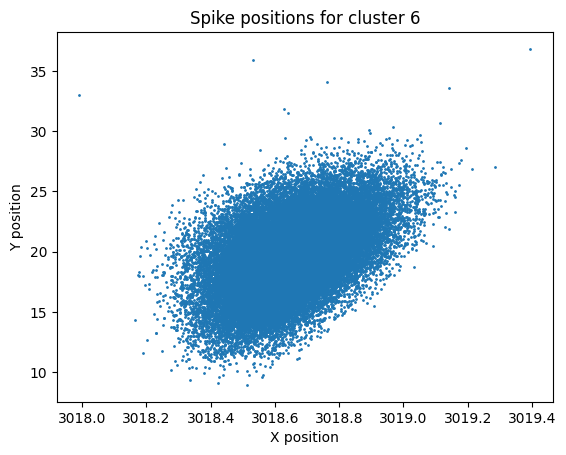

Peak channel: 39
Number of spikes: 39433


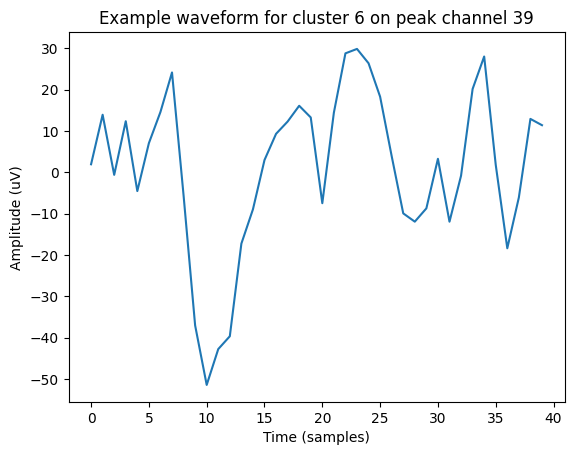

In [20]:
fs = P3_loc.get_sampling_frequency()

ms_before = 0.5
ms_after = 1.5

n_before = int(ms_before / 1000 * fs)
n_after = int(ms_after / 1000 * fs)

for cluster_id in range(ops['n_units_total']):
    if cluster_id == 6: 
        print(f"Cluster {cluster_id}:")
        indices = np.where(clu == cluster_id)[0]

        # location of spikes in space 
        spike_pos = spike_positions[indices]
        plt.figure()
        plt.scatter(spike_pos[:, 0], spike_pos[:, 1], s=1)
        plt.title(f"Spike positions for cluster {cluster_id}")
        plt.xlabel("X position")
        plt.ylabel("Y position")
        plt.show()

        # peak channel 
        peak_channel_id = chan_best_b[cluster_id] # chan_best a or b 
        peak_channel = chan_map[peak_channel_id]
        print(f"Peak channel: {peak_channel}")

        # number of spikes in cluster
        print(f"Number of spikes: {len(indices)}")

        # for each spike, extract the waveform on the peak channel 
        waveforms = np.empty((len(indices), n_before + n_after), dtype=np.float32)
        # they will be ordered by time since that's how the st and clu arrays are ordered

        for i, spike_idx in enumerate(indices):                 
            spike_time = st[spike_idx]

            start = spike_time - n_before
            end = spike_time + n_after

            waveforms[i] = P3_loc.get_traces(start_frame=start, end_frame=end, channel_ids=[peak_channel], return_in_uV=True)[:, 0]

            if i == 0:
                plt.figure()
                plt.plot(waveforms[i])
                plt.title(f"Example waveform for cluster {cluster_id} on peak channel {peak_channel}")
                plt.xlabel("Time (samples)")
                plt.ylabel("Amplitude (uV)")
                plt.show()

            #print(f"Spike time: {spike_time} samples, {spike_time/30000:.2f} seconds")

        waveforms = np.asarray(waveforms)

        break



In [22]:
print(f"Waveforms shape: {waveforms.shape}")
mean_waveform = waveforms.mean(axis=0) # TODO: consider the median 

Waveforms shape: (39433, 40)


/opt/miniconda3/envs/spike_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


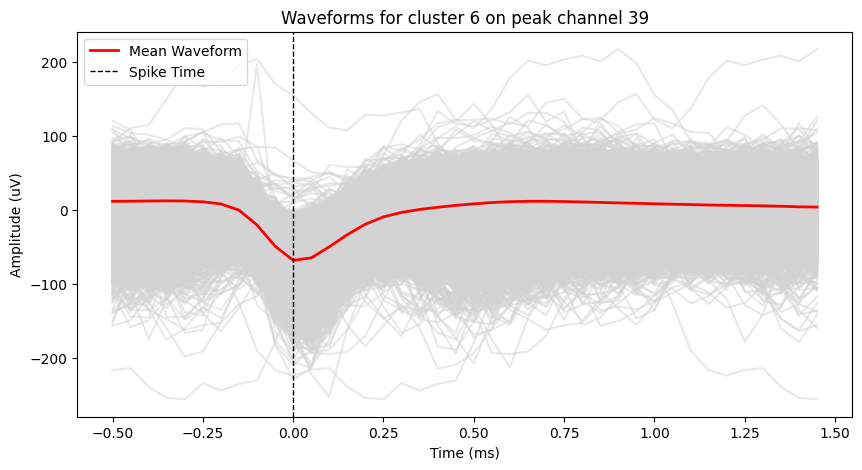

In [23]:
time_ms = (np.arange(waveforms.shape[1]) - n_before) / fs * 1000

plt.figure(figsize=(10, 5))
plt.plot(time_ms, waveforms.T, color='lightgray', alpha=0.5)
plt.plot(time_ms, waveforms.mean(axis=0), color='red', linewidth=2, label='Mean Waveform')
plt.axvline(0, color='black', linestyle='--', linewidth=1, label='Spike Time')
plt.title(f"Waveforms for cluster {cluster_id} on peak channel {peak_channel}")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (uV)")
plt.legend()
plt.show()

Threshold: r >= 0.8
Matching spikes: 19004/39433
Fraction matching: 0.482


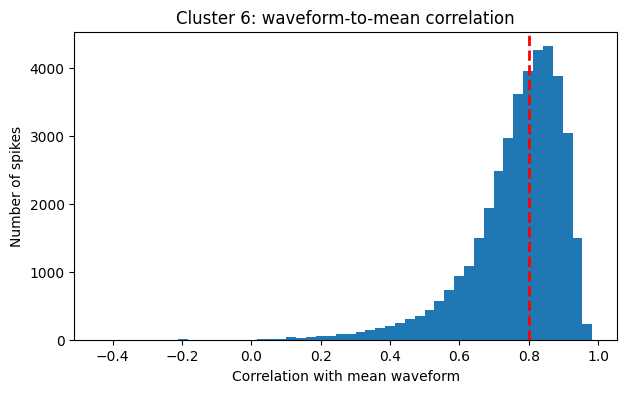

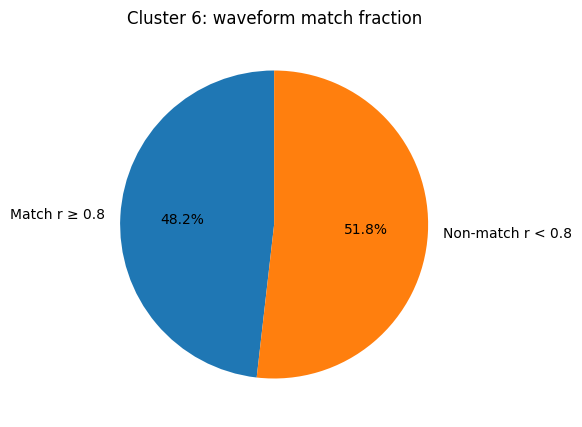

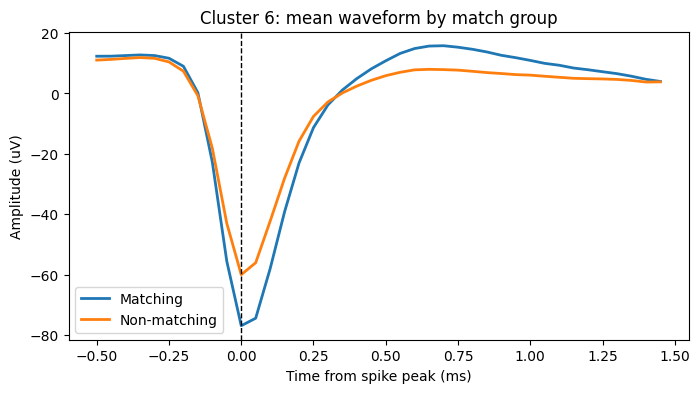

In [24]:
# center waveforms and mean
wf_centered = waveforms - waveforms.mean(axis=1, keepdims=True)
mean_centered = mean_waveform - mean_waveform.mean()

# Pearson correlation, vectorized
numerator = wf_centered @ mean_centered
denominator = np.linalg.norm(wf_centered, axis=1) * np.linalg.norm(mean_centered)

corrs = numerator / denominator


threshold = 0.8

is_match = corrs >= threshold

n_match = is_match.sum()
n_nonmatch = len(is_match) - n_match

print(f"Threshold: r >= {threshold}")
print(f"Matching spikes: {n_match}/{len(is_match)}")
print(f"Fraction matching: {n_match / len(is_match):.3f}")

plt.figure(figsize=(7, 4))

plt.hist(corrs, bins=50)
plt.axvline(threshold, color="red", linestyle="--", linewidth=2)

plt.xlabel("Correlation with mean waveform")
plt.ylabel("Number of spikes")
plt.title(f"Cluster {cluster_id}: waveform-to-mean correlation")
plt.show()

plt.figure(figsize=(5, 5))

plt.pie(
    [n_match, n_nonmatch],
    labels=[f"Match r ≥ {threshold}", f"Non-match r < {threshold}"],
    autopct="%1.1f%%",
    startangle=90,
)

plt.title(f"Cluster {cluster_id}: waveform match fraction")
plt.show()

time_ms = (np.arange(waveforms.shape[1]) - n_before) / fs * 1000

plt.figure(figsize=(8, 4))

plt.plot(time_ms, waveforms[is_match].mean(axis=0), linewidth=2, label="Matching")
plt.plot(time_ms, waveforms[~is_match].mean(axis=0), linewidth=2, label="Non-matching")

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Time from spike peak (ms)")
plt.ylabel("Amplitude (uV)")
plt.title(f"Cluster {cluster_id}: mean waveform by match group")
plt.legend()
plt.show()

In [25]:
print(f"Number of units total: {ops['n_units_total']}")
print(f"Number of spikes: {ops['n_spikes']}")

print(st.shape, clu.shape)

Number of units total: 66
Number of spikes: 574542
(574542,) (574542,)


In [26]:
print(f"templates array shape: {templates.shape}")
print(f"cluster array shape: {clu.shape}. This array contains the cluster ID of each spike. There are {len(np.unique(clu))} clusters")


templates array shape: (66, 41, 30)
cluster array shape: (574542,). This array contains the cluster ID of each spike. There are 66 clusters


***

## for data from other sorters 



In [3]:
import numpy as np
import pandas as pd

analyzer = si.load_sorting_analyzer(r"C:\Users\social\Desktop\temp_Brune\SpikeExplore\analyzers\KS4_M_curated")

"""job_kwargs = dict(n_jobs=8, chunk_duration="1s", progress_bar=True)
compute_dict = {
    'unit_locations': {},
    "spike_locations": {},
}

analyzer.compute(compute_dict, **job_kwargs)"""

def get_unit_peak_channel_from_waveforms(analyzer, unit_id, ms_before=0.5, ms_after=1.5, max_spikes=500):
    recording = analyzer.recording
    sorting = analyzer.sorting

    fs = recording.get_sampling_frequency()
    n_before = int(ms_before / 1000 * fs)
    n_after = int(ms_after / 1000 * fs)

    spike_times = sorting.get_unit_spike_train(unit_id).astype(np.int64)

    valid = (spike_times >= n_before) & (spike_times + n_after <= recording.get_num_frames())
    spike_times = spike_times[valid]

    if len(spike_times) > max_spikes:
        spike_times = np.random.choice(spike_times, max_spikes, replace=False)
        spike_times.sort()

    # extract all channels for a subset, only to find best channel
    wfs = []
    for t in spike_times:
        wfs.append(
            recording.get_traces(
                start_frame=int(t - n_before),
                end_frame=int(t + n_after),
                return_in_uV=True,
            )
        )

    wfs = np.asarray(wfs)  # spikes x samples x channels

    mean_wf = wfs.mean(axis=0)
    peak_channel_ind = np.ptp(mean_wf, axis=0).argmax()
    peak_channel_id = recording.get_channel_ids()[peak_channel_ind]

    return peak_channel_id, peak_channel_ind


def extract_all_peak_waveforms(analyzer, unit_id, peak_channel_id, ms_before=0.5, ms_after=1.5):
    recording = analyzer.recording
    sorting = analyzer.sorting

    fs = recording.get_sampling_frequency()
    n_before = int(ms_before / 1000 * fs)
    n_after = int(ms_after / 1000 * fs)
    n_samples = n_before + n_after

    spike_times = sorting.get_unit_spike_train(unit_id).astype(np.int64)

    valid = (spike_times >= n_before) & (spike_times + n_after <= recording.get_num_frames())
    spike_times = spike_times[valid]

    waveforms = np.empty((len(spike_times), n_samples), dtype=np.float32)

    for i, t in enumerate(spike_times):
        waveforms[i] = recording.get_traces(
            start_frame=int(t - n_before),
            end_frame=int(t + n_after),
            channel_ids=[peak_channel_id],
            return_in_uV=True,
        )[:, 0]

    return spike_times, waveforms

In [28]:
print(unit_ids)

[ 1  4  5  8 10 14 15 17 18 19 20 23 25 26 28 29 30 31 34 35 36 37 38 39
 41 42 43 21 13 11]


In [29]:
unit_ids = analyzer.sorting.get_unit_ids()
unit_locations = analyzer.get_extension("unit_locations").get_data()
spike_locations = analyzer.get_extension("spike_locations").get_data()
channel_locations = analyzer.recording.get_channel_locations()

unit_id = unit_ids[1]

peak_channel_id, peak_channel_ind = get_unit_peak_channel_from_waveforms(
    analyzer,
    unit_id,
    ms_before=0.5,
    ms_after=1.5,
)

spike_times, waveforms = extract_all_peak_waveforms(
    analyzer,
    unit_id,
    peak_channel_id,
    ms_before=0.5,
    ms_after=1.5,
)

unit_xy = unit_locations[list(unit_ids).index(unit_id)]
peak_xy = channel_locations[peak_channel_ind]

print("Unit:", unit_id)
print("Unit location:", unit_xy)
print("Peak channel:", peak_channel_id)
print("Peak channel location:", peak_xy)
print("Number of spikes:", len(spike_times))
print("Waveforms shape:", waveforms.shape)

Unit: 4
Unit location: [ 18.2532855  -14.60227604   1.80051297]
Peak channel: 39
Peak channel location: [18.26612904  0.        ]
Number of spikes: 24899
Waveforms shape: (24899, 40)


(186321,)


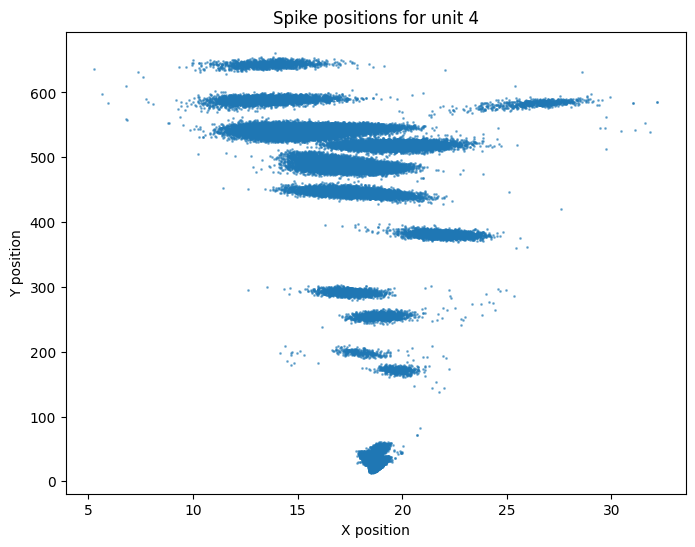

In [30]:
print(spike_locations.shape)

spike_x = spike_locations['x']
spike_y = spike_locations['y']

plt.figure(figsize=(8, 6))
plt.scatter(spike_x, spike_y, s=1, alpha=0.5)
plt.title(f"Spike positions for unit {unit_id}")
plt.xlabel("X position")
plt.ylabel("Y position")
plt.show()

In [27]:
import spikeinterface.widgets as sw
sw.plot_sorting_summary(analyzer, backend="spikeinterface_gui")

c:\Users\social\Desktop\temp_Brune\spikeinterface\venv_SI\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


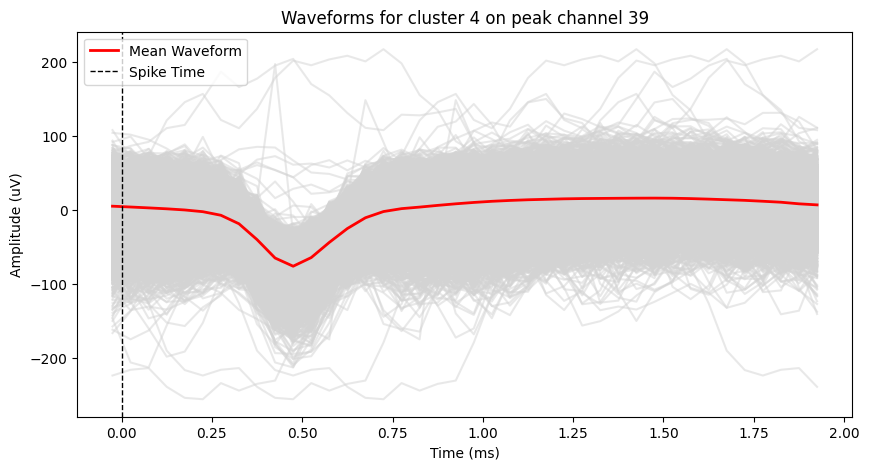

In [31]:
n_before = 0.5
n_after = 1.5
fs = 20000

mean_waveform = waveforms.mean(axis=0)
time_ms = (np.arange(waveforms.shape[1]) - n_before) / fs * 1000

plt.figure(figsize=(10, 5))
plt.plot(time_ms, waveforms.T, color='lightgray', alpha=0.5)
plt.plot(time_ms, waveforms.mean(axis=0), color='red', linewidth=2, label='Mean Waveform')
plt.axvline(0, color='black', linestyle='--', linewidth=1, label='Spike Time')
plt.title(f"Waveforms for cluster {unit_id} on peak channel {peak_channel_id}")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (uV)")
plt.legend()
plt.show()

In [32]:
channel_ids = analyzer.recording.get_channel_ids()

Threshold: r >= 0.8
Matching spikes: 14095/24899
Fraction matching: 0.566


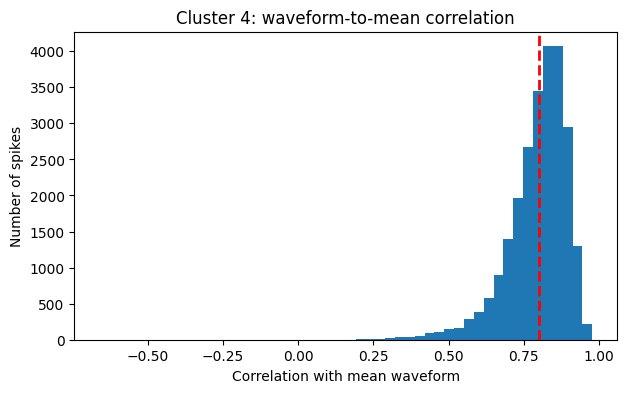

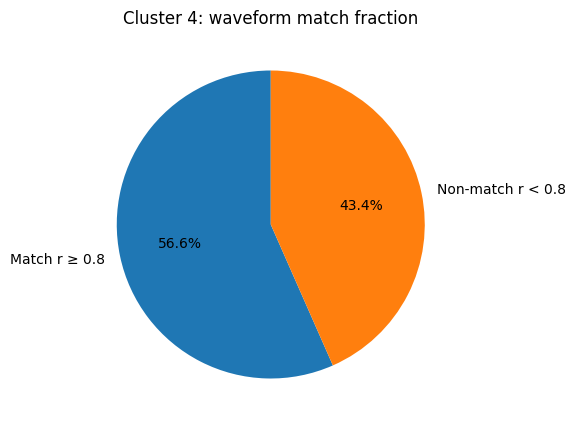

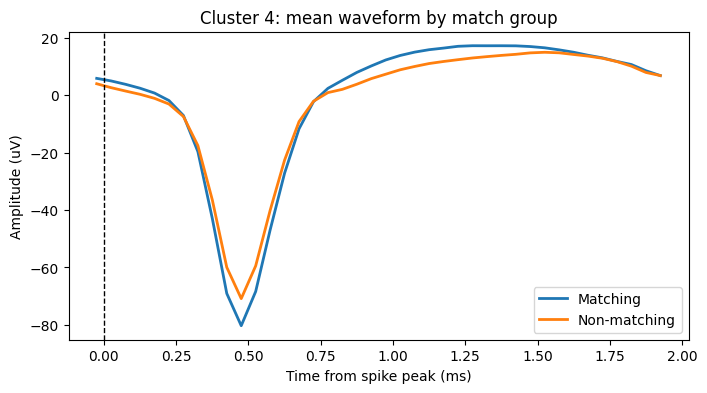

In [33]:
# center waveforms and mean
wf_centered = waveforms - waveforms.mean(axis=1, keepdims=True)
mean_centered = mean_waveform - mean_waveform.mean()

# Pearson correlation, vectorized
numerator = wf_centered @ mean_centered
denominator = np.linalg.norm(wf_centered, axis=1) * np.linalg.norm(mean_centered)

corrs = numerator / denominator


threshold = 0.8

is_match = corrs >= threshold

n_match = is_match.sum()
n_nonmatch = len(is_match) - n_match

print(f"Threshold: r >= {threshold}")
print(f"Matching spikes: {n_match}/{len(is_match)}")
print(f"Fraction matching: {n_match / len(is_match):.3f}")

plt.figure(figsize=(7, 4))

plt.hist(corrs, bins=50)
plt.axvline(threshold, color="red", linestyle="--", linewidth=2)

plt.xlabel("Correlation with mean waveform")
plt.ylabel("Number of spikes")
plt.title(f"Cluster {unit_id}: waveform-to-mean correlation")
plt.show()

plt.figure(figsize=(5, 5))

plt.pie(
    [n_match, n_nonmatch],
    labels=[f"Match r ≥ {threshold}", f"Non-match r < {threshold}"],
    autopct="%1.1f%%",
    startangle=90,
)

plt.title(f"Cluster {unit_id}: waveform match fraction")
plt.show()

time_ms = (np.arange(waveforms.shape[1]) - n_before) / fs * 1000

plt.figure(figsize=(8, 4))

plt.plot(time_ms, waveforms[is_match].mean(axis=0), linewidth=2, label="Matching")
plt.plot(time_ms, waveforms[~is_match].mean(axis=0), linewidth=2, label="Non-matching")

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Time from spike peak (ms)")
plt.ylabel("Amplitude (uV)")
plt.title(f"Cluster {unit_id}: mean waveform by match group")
plt.legend()
plt.show()

***

## comparing two different units from different sorters :)

In [ ]:
unit_a = {
    "unit_id": unit_id_a,
    "unit_location": unit_location_a,      # shape (2,)
    "spike_times": spike_times_a,          # shape (n_spikes,)
    "spike_locations": spike_locations_a,  # shape (n_spikes, 2)
    "waveforms": waveforms_a,              # shape (n_spikes, n_samples)
}

unit_b = {
    "unit_id": unit_id_b,
    "unit_location": unit_location_b,
    "spike_times": spike_times_b,
    "spike_locations": spike_locations_b,
    "waveforms": waveforms_b,
}

In [ ]:
def corr_1d(a, b):
    a = a - a.mean()
    b = b - b.mean()
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


def compare_units(unit_a, unit_b, fs, max_wfs=1000, time_tolerance_ms=0.5):
    out = {}

    # -------------------------
    # 1. Unit-location distance
    # -------------------------
    loc_a = np.asarray(unit_a["unit_location"])
    loc_b = np.asarray(unit_b["unit_location"])

    out["unit_distance_um"] = np.linalg.norm(loc_a - loc_b)

    # -------------------------
    # 2. Spike-location distance distribution
    # -------------------------
    spk_loc_a = np.asarray(unit_a["spike_locations"])
    spk_loc_b = np.asarray(unit_b["spike_locations"])

    n = min(len(spk_loc_a), len(spk_loc_b), max_wfs)

    idx_a = np.random.choice(len(spk_loc_a), n, replace=False)
    idx_b = np.random.choice(len(spk_loc_b), n, replace=False)

    spike_distances = np.linalg.norm(spk_loc_a[idx_a] - spk_loc_b[idx_b], axis=1)
    out["spike_location_distances_um"] = spike_distances

    # -------------------------
    # 3. Mean waveform correlation
    # -------------------------
    wfs_a = np.asarray(unit_a["waveforms"])
    wfs_b = np.asarray(unit_b["waveforms"])

    n_a = min(len(wfs_a), max_wfs)
    n_b = min(len(wfs_b), max_wfs)

    idx_a = np.random.choice(len(wfs_a), n_a, replace=False)
    idx_b = np.random.choice(len(wfs_b), n_b, replace=False)

    mean_a = np.median(wfs_a[idx_a], axis=0)
    mean_b = np.median(wfs_b[idx_b], axis=0)

    out["waveform_corr"] = corr_1d(mean_a, mean_b)
    out["mean_waveform_a"] = mean_a
    out["mean_waveform_b"] = mean_b

    # -------------------------
    # 4. Spike-time overlap
    # -------------------------
    tol = int(time_tolerance_ms / 1000 * fs)

    st_a = np.sort(unit_a["spike_times"].astype(np.int64))
    st_b = np.sort(unit_b["spike_times"].astype(np.int64))

    i = j = 0
    matches = 0

    while i < len(st_a) and j < len(st_b):
        dt = st_a[i] - st_b[j]

        if abs(dt) <= tol:
            matches += 1
            i += 1
            j += 1
        elif dt < 0:
            i += 1
        else:
            j += 1

    out["n_spikes_a"] = len(st_a)
    out["n_spikes_b"] = len(st_b)
    out["n_time_matches"] = matches
    out["precision_like"] = matches / len(st_b) if len(st_b) else np.nan
    out["recall_like"] = matches / len(st_a) if len(st_a) else np.nan
    out["agreement_score"] = matches / (len(st_a) + len(st_b) - matches)

    return out

In [ ]:
def plot_unit_comparison(result, fs, ms_before=0.5):
    mean_a = result["mean_waveform_a"]
    mean_b = result["mean_waveform_b"]

    time_ms = (np.arange(len(mean_a)) - int(ms_before / 1000 * fs)) / fs * 1000

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Waveforms
    axes[0].plot(time_ms, mean_a, label="Unit A")
    axes[0].plot(time_ms, mean_b, label="Unit B")
    axes[0].axvline(0, linestyle="--", color="black", linewidth=1)
    axes[0].set_title(f"Waveform corr = {result['waveform_corr']:.3f}")
    axes[0].set_xlabel("Time from spike peak [ms]")
    axes[0].set_ylabel("Amplitude")
    axes[0].legend()

    # Spike spatial distance histogram
    axes[1].hist(result["spike_location_distances_um"], bins=50)
    axes[1].axvline(result["unit_distance_um"], linestyle="--", color="red")
    axes[1].set_title(f"Unit distance = {result['unit_distance_um']:.1f} µm")
    axes[1].set_xlabel("Spike-location distance [µm]")
    axes[1].set_ylabel("Count")

    # Agreement summary
    labels = ["Matched", "A only", "B only"]
    matched = result["n_time_matches"]
    a_only = result["n_spikes_a"] - matched
    b_only = result["n_spikes_b"] - matched

    axes[2].pie(
        [matched, a_only, b_only],
        labels=labels,
        autopct="%1.1f%%",
        startangle=90,
    )
    axes[2].set_title(f"Agreement = {result['agreement_score']:.3f}")

    plt.tight_layout()
    plt.show()

In [ ]:
fs = analyzer.recording.get_sampling_frequency()

res = compare_units(unit_a, unit_b, fs=fs, max_wfs=1000, time_tolerance_ms=0.5)

plot_unit_comparison(res, fs=fs, ms_before=0.5)